In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def aggregate_roc_mean_p5_p95(roc_df, modelo, n_grid=401):
    """
    Agrega curvas ROC por Monte Carlo:
    - Interpola TPR sobre una malla común de FPR
    - Devuelve media y banda p5–p95 (por TPR)
    Retorna en espacio Specificity (TNR) vs TPR.
    """
    grid_fpr = np.linspace(0, 1, n_grid)

    tprs = []
    sub = roc_df[roc_df["modelo"] == modelo].copy()

    for mc_id, g in sub.groupby("mc_id"):
        g = g.sort_values("fpr")
        fpr = g["fpr"].to_numpy()
        tpr = g["tpr"].to_numpy()

        fpr_u, idx_u = np.unique(fpr, return_index=True)
        tpr_u = tpr[idx_u]

        tpr_i = np.interp(grid_fpr, fpr_u, tpr_u)
        tprs.append(tpr_i)

    tprs = np.vstack(tprs)  # (n_mc, n_grid)

    tpr_mean = np.mean(tprs, axis=0)
    tpr_p05  = np.percentile(tprs, 5, axis=0)
    tpr_p95  = np.percentile(tprs, 95, axis=0)

    spec = 1.0 - grid_fpr
    return spec, tpr_mean, tpr_p05, tpr_p95


def summarize_points_mean_p5_p95(thr_df, modelo, expected_points=("TPR95", "OPT", "TNR95")):
    """
    Para cada punto: retorna media y p5/p95 de (TNR, TPR) y de threshold.
    """
    sub = thr_df[thr_df["modelo"] == modelo].copy()
    sub = sub[sub["name"].isin(expected_points)].copy()

    rows = []
    for name, g in sub.groupby("name"):
        tnr = g["tnr"].to_numpy()
        tpr = g["tpr"].to_numpy()
        thr = g["threshold"].to_numpy()

        rows.append({
            "name": name,
            "tnr_mean": float(np.mean(tnr)),
            "tnr_p05":  float(np.percentile(tnr, 5)),
            "tnr_p95":  float(np.percentile(tnr, 95)),
            "tpr_mean": float(np.mean(tpr)),
            "tpr_p05":  float(np.percentile(tpr, 5)),
            "tpr_p95":  float(np.percentile(tpr, 95)),
            "thr_mean": float(np.mean(thr)),
            "thr_p05":  float(np.percentile(thr, 5)),
            "thr_p95":  float(np.percentile(thr, 95)),
            "n_mc": int(len(g))
        })

    order = {"TPR95": 0, "OPT": 1, "TNR95": 2}
    rows = sorted(rows, key=lambda r: order.get(r["name"], 99))
    return pd.DataFrame(rows)


def plot_roc_with_band_and_points_mean(roc_df, thr_df, modelo, n_grid=401, title=None):
    spec, tpr_mean, tpr_p05, tpr_p95 = aggregate_roc_mean_p5_p95(roc_df, modelo, n_grid=n_grid)
    pts = summarize_points_mean_p5_p95(thr_df, modelo, expected_points=("TPR95", "OPT", "TNR95"))

    fig, ax = plt.subplots(figsize=(6, 7))

    ax.fill_between(spec, tpr_p05, tpr_p95, alpha=0.25, label="Banda p5–p95")
    ax.plot(spec, tpr_mean, linewidth=2, label="ROC media")

    x = np.linspace(0, 1, 200)
    ax.plot(x, 1 - x, linewidth=1, color="gray", linestyle="--", alpha=0.9)

    for _, r in pts.iterrows():
        x_mean = r["tnr_mean"]
        y_mean = r["tpr_mean"]
        xerr = [[x_mean - r["tnr_p05"]], [r["tnr_p95"] - x_mean]]
        yerr = [[y_mean - r["tpr_p05"]], [r["tpr_p95"] - y_mean]]

        lbl = (f'{r["name"]}: Prob={r["thr_mean"]:.3f},\n '
               f'TPR={100*r["tpr_mean"]:.1f}%, TNR={100*r["tnr_mean"]:.1f}%')

        ax.errorbar(x_mean, y_mean, xerr=xerr, yerr=yerr, fmt="o", capsize=3, label=lbl)

    ax.set_xlabel("Specificity (TNR)")
    ax.set_ylabel("Sensitivity (TPR)")
    ax.set_xlim(1.0, 0.0)
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.3)

    if title is None:
        title = f"ROC agregada (media + p5–p95) — {modelo}"
    ax.set_title(title)

    # ✅ leyenda dentro, abajo-derecha
    ax.legend(loc="lower right", frameon=True, fontsize=9)

    plt.tight_layout()
    return fig, ax, pts



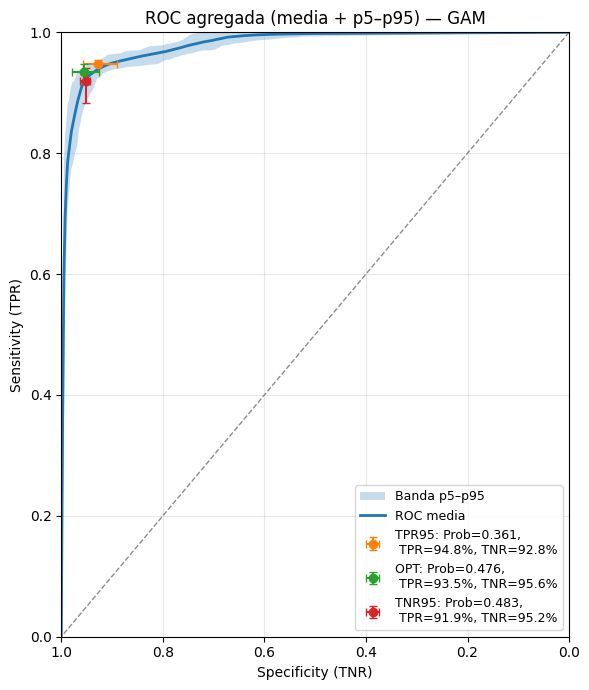

    name  tnr_mean   tnr_p05   tnr_p95  tpr_mean   tpr_p05   tpr_p95  \
0  TPR95  0.927717  0.890237  0.957669  0.947730  0.947368  0.954887   
1    OPT  0.955762  0.924808  0.979798  0.934597  0.917293  0.947368   
2  TNR95  0.951517  0.943205  0.963414  0.918820  0.883459  0.940299   

   thr_mean   thr_p05   thr_p95  n_mc  
0  0.360923  0.263000  0.452867    91  
1  0.475678  0.362854  0.593235    91  
2  0.483067  0.363513  0.613418    91  


In [4]:

roc_path = "/home/oisanchezp/Thesis/data/processed/roc_curves_paquetec_T1_P33_MC100.csv"
thr_path = "/home/oisanchezp/Thesis/data/processed/roc_threshold_points_paquetec_T1_P33_MC100.csv"

roc_df = pd.read_csv(roc_path)
thr_df = pd.read_csv(thr_path)

fig, ax, pts_gam = plot_roc_with_band_and_points_mean(roc_df, thr_df, modelo="GAM")
plt.show()

print(pts_gam)


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def aggregate_roc_mean_p5_p95(roc_df, modelo, n_grid=401):
    """
    Agrega curvas ROC por Monte Carlo:
    - Interpola TPR sobre una malla común de FPR
    - Devuelve media y banda p5–p95 (por TPR)
    Retorna en espacio Specificity (TNR) vs TPR.
    """
    grid_fpr = np.linspace(0, 1, n_grid)

    tprs = []
    sub = roc_df[roc_df["modelo"] == modelo].copy()

    for mc_id, g in sub.groupby("mc_id"):
        g = g.sort_values("fpr")
        fpr = g["fpr"].to_numpy()
        tpr = g["tpr"].to_numpy()

        fpr_u, idx_u = np.unique(fpr, return_index=True)
        tpr_u = tpr[idx_u]

        tpr_i = np.interp(grid_fpr, fpr_u, tpr_u)
        tprs.append(tpr_i)

    tprs = np.vstack(tprs)  # (n_mc, n_grid)

    tpr_mean = np.mean(tprs, axis=0)
    tpr_p05  = np.percentile(tprs, 5, axis=0)
    tpr_p95  = np.percentile(tprs, 95, axis=0)

    spec = 1.0 - grid_fpr
    return spec, tpr_mean, tpr_p05, tpr_p95


def summarize_points_mean_p5_p95(thr_df, modelo, expected_points=("TPR95", "TNR95")):
    """
    Para cada punto: retorna media y p5/p95 de (TNR, TPR) y de threshold.
    """
    sub = thr_df[thr_df["modelo"] == modelo].copy()
    sub = sub[sub["name"].isin(expected_points)].copy()

    rows = []
    for name, g in sub.groupby("name"):
        tnr = g["tnr"].to_numpy()
        tpr = g["tpr"].to_numpy()
        thr = g["threshold"].to_numpy()

        rows.append({
            "name": name,
            "tnr_mean": float(np.mean(tnr)),
            "tnr_p05":  float(np.percentile(tnr, 5)),
            "tnr_p95":  float(np.percentile(tnr, 95)),
            "tpr_mean": float(np.mean(tpr)),
            "tpr_p05":  float(np.percentile(tpr, 5)),
            "tpr_p95":  float(np.percentile(tpr, 95)),
            "thr_mean": float(np.mean(thr)),
            "thr_p05":  float(np.percentile(thr, 5)),
            "thr_p95":  float(np.percentile(thr, 95)),
            "n_mc": int(len(g))
        })

    order = {"TPR95": 0, "TNR95": 1}
    rows = sorted(rows, key=lambda r: order.get(r["name"], 99))
    return pd.DataFrame(rows)


def plot_roc_with_band_and_points_mean(roc_df, thr_df, modelo, n_grid=401, title=None):
    spec, tpr_mean, tpr_p05, tpr_p95 = aggregate_roc_mean_p5_p95(roc_df, modelo, n_grid=n_grid)
    pts = summarize_points_mean_p5_p95(thr_df, modelo, expected_points=("TPR95", "TNR95"))

    fig, ax = plt.subplots(figsize=(6, 7))

    ax.fill_between(spec, tpr_p05, tpr_p95, alpha=0.25, label="Banda p5–p95")
    ax.plot(spec, tpr_mean, linewidth=2, label="ROC media")

    x = np.linspace(0, 1, 200)
    ax.plot(x, 1 - x, linewidth=1, color="gray", linestyle="--", alpha=0.9)

    for _, r in pts.iterrows():
        x_mean = r["tnr_mean"]
        y_mean = r["tpr_mean"]
        xerr = [[x_mean - r["tnr_p05"]], [r["tnr_p95"] - x_mean]]
        yerr = [[y_mean - r["tpr_p05"]], [r["tpr_p95"] - y_mean]]

        lbl = (f'{r["name"]}: Prob={r["thr_mean"]:.3f},\n '
               f'TPR={100*r["tpr_mean"]:.1f}%, TNR={100*r["tnr_mean"]:.1f}%')

        ax.errorbar(x_mean, y_mean, xerr=xerr, yerr=yerr, fmt="o", capsize=3, label=lbl)

    ax.set_xlabel("Specificity (TNR)")
    ax.set_ylabel("Sensitivity (TPR)")
    ax.set_xlim(1.0, 0.0)
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.3)

    if title is None:
        title = f"ROC — {modelo}"
    ax.set_title(title)

    ax.legend(loc="lower right", frameon=True, fontsize=9)
    plt.tight_layout()
    return fig, ax, pts


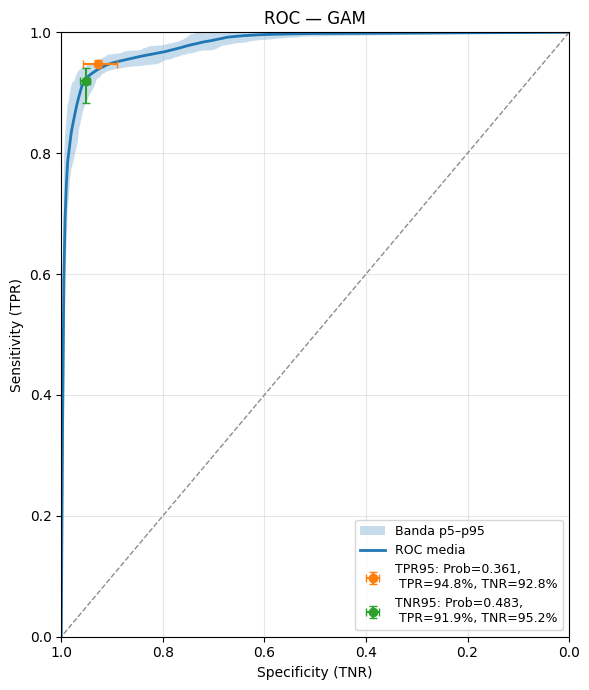

    name  tnr_mean   tnr_p05   tnr_p95  tpr_mean   tpr_p05   tpr_p95  \
0  TPR95  0.927717  0.890237  0.957669   0.94773  0.947368  0.954887   
1  TNR95  0.951517  0.943205  0.963414   0.91882  0.883459  0.940299   

   thr_mean   thr_p05   thr_p95  n_mc  
0  0.360923  0.263000  0.452867    91  
1  0.483067  0.363513  0.613418    91  


In [9]:

roc_path = "/home/oisanchezp/Thesis/data/processed/roc_curves_paquetec_T1_P33_MC100.csv"
thr_path = "/home/oisanchezp/Thesis/data/processed/roc_threshold_points_paquetec_T1_P33_MC100.csv"

roc_df = pd.read_csv(roc_path)
thr_df = pd.read_csv(thr_path)

fig, ax, pts_gam = plot_roc_with_band_and_points_mean(roc_df, thr_df, modelo="GAM")
plt.show()

print(pts_gam)